## **Image Data Enrichment - Open CV for MNIST**

The objective of this Python notebook is to compare 6 different image data enrichment techniques on the MNIST dataset, via OpenCV.

The methods used here are:

- No Processing
- Rotation
- Translation
- Scaling
- Noise
- Blur


### **Data Preparation**

This data below is to importe the MNIST dataset after the cleaning operation of MinMax Scaling via openCV, which has the best image cleaning effect after comparison.

In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from keras.datasets import mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.optimizers import Adam
from sklearn.decomposition import PCA

# Load MNIST
(trainImg, trainLabel), (testImg, testLabel) = mnist.load_data()

trainLabelCategorical = to_categorical(trainLabel, 10)
testLabelCategorical  = to_categorical(testLabel, 10)



In [29]:
PCA_COMPONENTS = 100 

def pca_cleaning(img):
    x = img.astype(np.float32).reshape(1, -1).T

    mean, eigenvectors = cv2.PCACompute(x, mean=None, maxComponents=PCA_COMPONENTS)

    coeff = cv2.PCAProject(x, mean, eigenvectors)

    recon = cv2.PCABackProject(coeff, mean, eigenvectors)

    recon = np.clip(recon, 0, 255)

    return recon.reshape(28, 28).astype(np.float32)

### **Image Data Enrichment Methods**

In [5]:
# Method 1 - No Processing
def NoProcessing(img):
    return img

In [30]:
# Method 2 - Rotation
def Rotation(img, angle=25):
    rows, cols = img.shape
    M = cv2.getRotationMatrix2D((cols/2, rows/2), angle=np.random.randint(-angle, angle), scale=1)
    return cv2.warpAffine(img, M, (cols, rows), borderMode=cv2.BORDER_REPLICATE)

In [34]:
# Method 3 - Translation
def Translation(img):
    M = np.float32([
        [1, 0, np.random.randint(-5, 6)],
        [0, 1, np.random.randint(-5, 6)]
    ])
    return cv2.warpAffine(img, M, img.shape, borderMode=cv2.BORDER_REPLICATE)

In [35]:
# Method 4 - Scaling
def Scaling(img, scale_range=(0.9, 1.2)):
    scale = np.random.uniform(scale_range[0], scale_range[1])
    h, w = img.shape[:2]
    scaled = cv2.resize(img, None, fx=scale, fy=scale)

  
    return cv2.resize(scaled, (w,h))


In [36]:
# Method 5 - Noise
def Noise(img):
    sigma = np.random.uniform(10, 25)
    noise = np.random.normal(0, sigma, img.shape)
    out = img + noise
    return np.clip(out, 0, 255)

In [37]:
# Method 6 - Blur
def Blur(img, ksize=(5,5)):
    return cv2.GaussianBlur(img, ksize, 0)

### **Simple RNN Model**

In [11]:
def initRNN():
    model = Sequential([
        SimpleRNN(128, input_shape=(28, 28)),
        Dense(10, activation="softmax")
    ])
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

### **Model Training and Evaluation**

In [26]:
def train_with_augmentation(cleaningMethod, augmentMethod):
    train_processed = np.array([
        augmentMethod(cleaningMethod(img)) for img in trainImg
    ])

    test_processed = np.array([
        cleaningMethod(img) for img in testImg
    ])

    # Normalization
    train_processed = train_processed / 255.0
    test_processed  = test_processed / 255.0

    # RNN reshape
    train_processed = train_processed.reshape((-1, 28, 28))
    test_processed  = test_processed.reshape((-1, 28, 28))

    # Training
    model = initRNN()
    model.fit(train_processed, trainLabelCategorical, epochs=5, batch_size=64, verbose=1)

    return model.evaluate(test_processed, testLabelCategorical)

### **Comparison**

In [38]:
augmentations = {
    "No Processing": NoProcessing,
    "Rotation": Rotation,
    "Translation": Translation,
    "Scaling": Scaling,
    "Noise": Noise,
    "Blur": Blur
}

results = {}

for name, aug in augmentations.items():
    print(f"\n=== Image Enrichment：{name} ===")
    loss, acc = train_with_augmentation(pca_cleaning, aug)
    results[name] = acc


=== Image Enrichment：No Processing ===
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 171s 182ms/step - accuracy: 0.8091 - loss: 0.6275
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 170s 182ms/step - accuracy: 0.9394 - loss: 0.2102
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 185s 197ms/step - accuracy: 0.9536 - loss: 0.1590
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 185s 197ms/step - accuracy: 0.9597 - loss: 0.1386
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 186s 198ms/step - accuracy: 0.9646 - loss: 0.1224
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9568 - loss: 0.1443

=== Image Enrichment：Rotation ===
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 193s 205ms/step - accuracy: 0.7437 - loss: 0.8031
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 195s 207ms/step - accuracy: 0.9078 - loss: 0.3095
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 197s 210ms/step - accuracy: 0.9249 - loss: 0.2545
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 254s 271ms/step - accuracy: 0.9355 - loss: 0.2188
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 284s 303

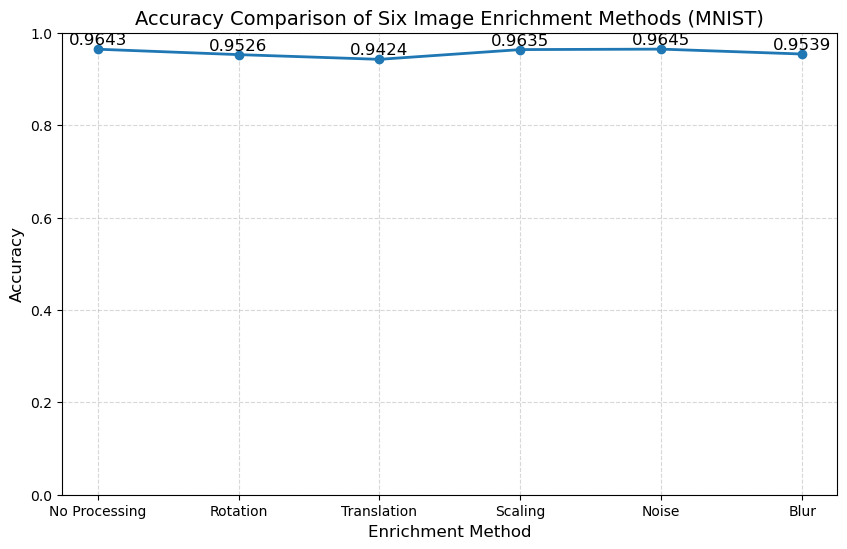

In [39]:
import matplotlib.pyplot as plt

methods = list(results.keys())
acc_values = list(results.values())

plt.figure(figsize=(10,6))
plt.plot(methods, acc_values, marker='o', linewidth=2)

plt.title("Accuracy Comparison of Six Image Enrichment Methods (MNIST)", fontsize=14)
plt.xlabel("Enrichment Method", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(0, 1)

for i, acc in enumerate(acc_values):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha='center', fontsize=12)

plt.show()


- The result of line chart indicates that the image enrichment method with the worst effect is the Translation, while the best one is the Noise.
- In addition, the Scaler, Rotation and Blur have similar performances.
- With no processing, the accuracy still remains considerable.